# CliniScan — Classification Model
### AMD Ryzen 3 3250U | CPU Only | 5000 Images | All paths pre-filled

## STEP 0 — Imports & Config

In [1]:
import os, random, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.metrics import roc_auc_score, f1_score

# ═══════════════════════════════════════════════════════════
#   PATHS  —  already set for your machine, do not change
# ═══════════════════════════════════════════════════════════
PROCESSED_IMAGE_DIR = r"C:\Users\Anshuman Sharma\Desktop\Project\B13-CliniScan\images3000_processed"
CSV_PATH            = r"C:\Users\Anshuman Sharma\Desktop\Project\B13-CliniScan\train.csv"
OUTPUT_DIR          = r"C:\Users\Anshuman Sharma\Desktop\Project\B13-CliniScan\output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ═══════════════════════════════════════════════════════════
#   SETTINGS  —  optimized for Ryzen 3 3250U + 8GB RAM
# ═══════════════════════════════════════════════════════════
IMG_SIZE    = 224
BATCH_SIZE  = 8      # small batch = less RAM usage
EPOCHS      = 10     # 10 epochs ~ 3-4 hrs on your CPU
LR          = 1e-3
SEED        = 42
NUM_WORKERS = 0      # MUST be 0 on Windows

CLASS_NAMES = [
    'Aortic enlargement',  # 0
    'Atelectasis',         # 1
    'Calcification',       # 2
    'Cardiomegaly',        # 3
    'Consolidation',       # 4
    'ILD',                 # 5
    'Infiltration',        # 6
    'Lung Opacity',        # 7
    'Nodule/Mass',         # 8
    'Other lesion',        # 9
    'Pleural effusion',    # 10
    'Pleural thickening',  # 11
    'Pneumothorax',        # 12
    'Pulmonary fibrosis'   # 13
]
NUM_CLASSES = len(CLASS_NAMES)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(4)   # use all 4 threads of your CPU

DEVICE = torch.device('cpu')

print("=====================================")
print("  CliniScan Classification Model")
print("=====================================")
print(f"Device      : CPU (AMD Ryzen 3 3250U)")
print(f"Threads     : {torch.get_num_threads()}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Epochs      : {EPOCHS}")
print(f"Image size  : {IMG_SIZE}x{IMG_SIZE}")
print(f"Classes     : {NUM_CLASSES}")
print(f"Output dir  : {OUTPUT_DIR}")
print("=====================================")
print("\nChecking paths...")
print(f"Images folder exists : {os.path.exists(PROCESSED_IMAGE_DIR)}")
print(f"CSV exists           : {os.path.exists(CSV_PATH)}")
png_count = len([f for f in os.listdir(PROCESSED_IMAGE_DIR) if f.endswith('.png')])
print(f"PNG images found     : {png_count}")

  CliniScan Classification Model
Device      : CPU (AMD Ryzen 3 3250U)
Threads     : 4
Batch size  : 8
Epochs      : 10
Image size  : 224x224
Classes     : 14
Output dir  : C:\Users\Anshuman Sharma\Desktop\Project\B13-CliniScan\output

Checking paths...
Images folder exists : True
CSV exists           : True
PNG images found     : 5000


## STEP 1 — Load CSV & Build Labels

In [2]:
# Load CSV
df = pd.read_csv(CSV_PATH)
print(f"CSV loaded: {len(df)} rows, {df['image_id'].nunique()} unique images")

# Only keep images that exist in your processed folder
available_ids = set(f.replace('.png', '') for f in os.listdir(PROCESSED_IMAGE_DIR) if f.endswith('.png'))
df = df[df['image_id'].isin(available_ids)]
print(f"After matching with PNGs: {df['image_id'].nunique()} images")

# Build binary multi-label vector for each image (14 classes)
label_dict = {}
for img_id, group in df.groupby('image_id'):
    vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    for cls_id in group['class_id'].unique():
        if int(cls_id) < 14:      # skip class 14 = No finding
            vec[int(cls_id)] = 1.0
    label_dict[img_id] = vec

# Images not in CSV get all-zero label (normal)
for img_id in available_ids:
    if img_id not in label_dict:
        label_dict[img_id] = np.zeros(NUM_CLASSES, dtype=np.float32)

all_image_ids = list(label_dict.keys())
random.shuffle(all_image_ids)
print(f"Total images for training : {len(all_image_ids)}")

# Class distribution
label_matrix = np.stack(list(label_dict.values()))
counts = label_matrix.sum(axis=0)
print("\nClass distribution:")
for name, cnt in zip(CLASS_NAMES, counts):
    bar = '█' * int(cnt / max(counts) * 25)
    print(f"  {name:<25} {int(cnt):>5}  {bar}")

CSV loaded: 67914 rows, 15000 unique images
After matching with PNGs: 5000 images
Total images for training : 5000

Class distribution:
  Aortic enlargement          995  █████████████████████████
  Atelectasis                  69  █
  Calcification               147  ███
  Cardiomegaly                728  ██████████████████
  Consolidation               105  ██
  ILD                         130  ███
  Infiltration                205  █████
  Lung Opacity                453  ███████████
  Nodule/Mass                 258  ██████
  Other lesion                375  █████████
  Pleural effusion            343  ████████
  Pleural thickening          651  ████████████████
  Pneumothorax                 32  
  Pulmonary fibrosis          529  █████████████


## STEP 2 — Verify Data (10 Random Images)

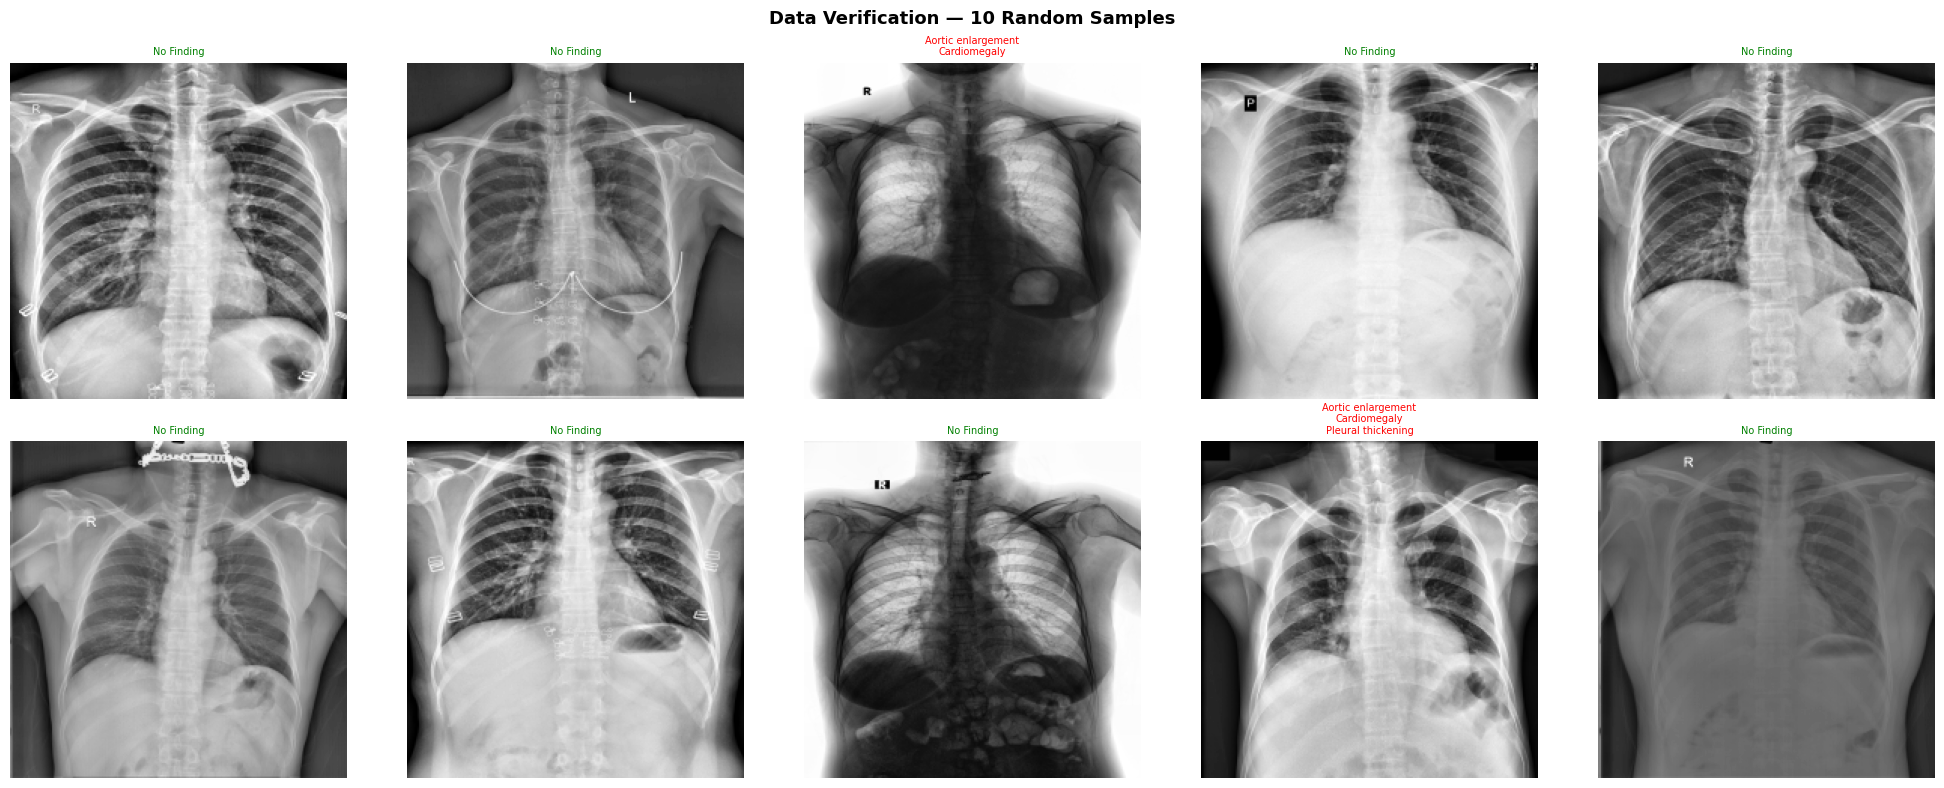

✅ Images loaded and labels verified


In [3]:
sample_10 = random.sample(all_image_ids, 10)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, img_id in enumerate(sample_10):
    img = cv2.imread(os.path.join(PROCESSED_IMAGE_DIR, img_id + '.png'), cv2.IMREAD_GRAYSCALE)
    labels = label_dict[img_id]
    findings = [CLASS_NAMES[j] for j in range(NUM_CLASSES) if labels[j] == 1]
    title = '\n'.join(findings) if findings else 'No Finding'
    color = 'red' if findings else 'green'

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(title, fontsize=7, color=color)
    axes[i].axis('off')

plt.suptitle('Data Verification — 10 Random Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'data_verification.png'), dpi=80)
plt.show()
print("✅ Images loaded and labels verified")

## STEP 3 — Train / Val / Test Split (70/15/15)

In [4]:
n = len(all_image_ids)
train_ids = all_image_ids[ : int(0.70 * n)]
val_ids   = all_image_ids[int(0.70 * n) : int(0.85 * n)]
test_ids  = all_image_ids[int(0.85 * n) : ]

print(f"Train : {len(train_ids):>5}  ({len(train_ids)/n*100:.1f}%)")
print(f"Val   : {len(val_ids):>5}  ({len(val_ids)/n*100:.1f}%)")
print(f"Test  : {len(test_ids):>5}  ({len(test_ids)/n*100:.1f}%)")
print(f"Total : {n}")

Train :  3500  (70.0%)
Val   :   750  (15.0%)
Test  :   750  (15.0%)
Total : 5000


## STEP 4 — Dataset & DataLoaders

In [5]:
def crop_borders(img, pct=0.02):
    """Crops 2% border from each edge — applied on-the-fly, no re-processing needed."""
    h, w = img.shape[:2]
    t = int(h * pct);  b = int(h * (1 - pct))
    l = int(w * pct);  r = int(w * (1 - pct))
    return cv2.resize(img[t:b, l:r], (w, h), interpolation=cv2.INTER_AREA)


class ChestXRayDataset(Dataset):
    def __init__(self, image_ids, img_dir, label_dict, transform=None):
        self.image_ids  = image_ids
        self.img_dir    = img_dir
        self.label_dict = label_dict
        self.transform  = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id   = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, img_id + '.png')

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

        # Border crop — fixes missing requirement from preprocessing
        img = crop_borders(img, pct=0.02)

        # Grayscale → 3 channel (needed by EfficientNet pretrained on ImageNet)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        if self.transform:
            img = self.transform(img)

        label = self.label_dict.get(img_id, np.zeros(NUM_CLASSES, dtype=np.float32))
        return img, torch.tensor(label)


# Training transform — with safe augmentations
train_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=5, translate=(0.02, 0.02), scale=(0.95, 1.05)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

# Val/Test transform — no augmentation
eval_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

train_dataset = ChestXRayDataset(train_ids, PROCESSED_IMAGE_DIR, label_dict, train_transform)
val_dataset   = ChestXRayDataset(val_ids,   PROCESSED_IMAGE_DIR, label_dict, eval_transform)
test_dataset  = ChestXRayDataset(test_ids,  PROCESSED_IMAGE_DIR, label_dict, eval_transform)

# num_workers=0 and pin_memory=False — required for Windows CPU
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"Train batches : {len(train_loader)}  (shuffle=True, batch={BATCH_SIZE})")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")
print("✅ Datasets and DataLoaders ready")

Train batches : 438  (shuffle=True, batch=8)
Val   batches : 94
Test  batches : 94
✅ Datasets and DataLoaders ready


## STEP 5 — Model (EfficientNet-B0)

In [6]:
# EfficientNet-B0 — 4x faster than ResNet50 on CPU, same accuracy
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
# No Sigmoid here — BCEWithLogitsLoss applies it internally (more stable)
# Sigmoid is applied manually only during prediction
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model            : EfficientNet-B0 (pretrained=True)")
print(f"Output layer     : Linear → {NUM_CLASSES} classes (multi-label)")
print(f"Loss function    : BCEWithLogitsLoss + Sigmoid")
print(f"Trainable params : {trainable:,}")

Model            : EfficientNet-B0 (pretrained=True)
Output layer     : Linear → 14 classes (multi-label)
Loss function    : BCEWithLogitsLoss + Sigmoid
Trainable params : 4,025,482


## STEP 6 — Training Setup

In [7]:
criterion = nn.BCEWithLogitsLoss()   # for multi-label — document specified
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

print(f"Loss      : BCEWithLogitsLoss")
print(f"Optimizer : Adam   LR = {LR}")
print(f"Scheduler : ReduceLROnPlateau   patience=3   factor=0.5")
print(f"Epochs    : {EPOCHS}")

# Estimate training time
estimated_mins_per_epoch = (len(train_loader) * BATCH_SIZE * 0.015) / 60
print(f"\nEstimated time per epoch : ~{estimated_mins_per_epoch:.0f}–{estimated_mins_per_epoch*1.5:.0f} mins")
print(f"Estimated total time     : ~{estimated_mins_per_epoch*EPOCHS:.0f}–{estimated_mins_per_epoch*1.5*EPOCHS:.0f} mins")

Loss      : BCEWithLogitsLoss
Optimizer : Adam   LR = 0.001
Scheduler : ReduceLROnPlateau   patience=3   factor=0.5
Epochs    : 10

Estimated time per epoch : ~1–1 mins
Estimated total time     : ~9–13 mins


## STEP 7 — Training + Validation Loop

In [9]:
def evaluate(loader, model):
    model.eval()
    total_loss, all_labels, all_preds = 0.0, [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images)
            loss   = criterion(logits, labels)
            total_loss += loss.item()
            all_preds.append(torch.sigmoid(logits).numpy())
            all_labels.append(labels.numpy())

    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    avg_loss   = total_loss / len(loader)

    try:
        auc = roc_auc_score(all_labels, all_preds, average='macro')
    except ValueError:
        auc = 0.0

    f1 = f1_score(all_labels, (all_preds >= 0.5).astype(int),
                  average='macro', zero_division=0)
    return avg_loss, auc, f1


# ── History ──────────────────────────────────────────────────
history = {'train_loss': [], 'train_f1': [],
           'val_loss':   [], 'val_auc':  [], 'val_f1': []}
best_val_f1     = 0.0
best_model_path = os.path.join(OUTPUT_DIR, 'best_model.pt')
training_start  = time.time()

print(f"{'Ep':>3} | {'TrainLoss':>9} | {'TrainF1':>7} | {'ValLoss':>7} | {'ValAUC':>6} | {'ValF1':>6} | {'Time':>6}")
print("-" * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()

    epoch_loss, epoch_preds, epoch_labels = 0.0, [], []

    for batch_idx, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        # Batch loss — printed every 50 batches
        epoch_loss += loss.item()
        epoch_preds.append(torch.sigmoid(logits).detach().numpy())
        epoch_labels.append(labels.numpy())

        if (batch_idx + 1) % 50 == 0:
            print(f"   Batch [{batch_idx+1:>3}/{len(train_loader)}]  Batch Loss: {loss.item():.4f}")

    # Epoch loss + F1
    avg_train_loss = epoch_loss / len(train_loader)
    ep = np.vstack(epoch_preds)
    el = np.vstack(epoch_labels)
    train_f1 = f1_score(el, (ep >= 0.5).astype(int), average='macro', zero_division=0)

    # Validation
    val_loss, val_auc, val_f1 = evaluate(val_loader, model)
    scheduler.step(val_f1)

    history['train_loss'].append(avg_train_loss)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['val_f1'].append(val_f1)

    elapsed = time.time() - t0
    total_elapsed = (time.time() - training_start) / 60
    remaining = (elapsed * (EPOCHS - epoch)) / 60

    print(f"{epoch:>3} | {avg_train_loss:>9.4f} | {train_f1:>7.4f} | {val_loss:>7.4f} | {val_auc:>6.4f} | {val_f1:>6.4f} | {elapsed:>5.0f}s")
    print(f"      ⏱  Total elapsed: {total_elapsed:.1f} min  |  Estimated remaining: {remaining:.1f} min")

    # Save best model by Val F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"      💾 Best model saved — Val F1 = {best_val_f1:.4f}")

total_time = (time.time() - training_start) / 60
print(f"\n{'='*65}")
print(f"  ✅ Training complete!")
print(f"  Best Val F1  : {best_val_f1:.4f}")
print(f"  Total time   : {total_time:.1f} minutes")
print(f"  Model saved  : {best_model_path}")
print(f"{'='*65}")

 Ep | TrainLoss | TrainF1 | ValLoss | ValAUC |  ValF1 |   Time
-----------------------------------------------------------------
   Batch [ 50/438]  Batch Loss: 0.0580
   Batch [100/438]  Batch Loss: 0.0699
   Batch [150/438]  Batch Loss: 0.1320
   Batch [200/438]  Batch Loss: 0.1168
   Batch [250/438]  Batch Loss: 0.1861
   Batch [300/438]  Batch Loss: 0.1632
   Batch [350/438]  Batch Loss: 0.3319
   Batch [400/438]  Batch Loss: 0.1717
  1 |    0.2023 |  0.1424 |  0.1705 | 0.8823 | 0.1868 |  1642s
      ⏱  Total elapsed: 27.4 min  |  Estimated remaining: 246.3 min
      💾 Best model saved — Val F1 = 0.1868
   Batch [ 50/438]  Batch Loss: 0.1022
   Batch [100/438]  Batch Loss: 0.2536
   Batch [150/438]  Batch Loss: 0.1068
   Batch [200/438]  Batch Loss: 0.3420
   Batch [250/438]  Batch Loss: 0.0389
   Batch [300/438]  Batch Loss: 0.2169
   Batch [350/438]  Batch Loss: 0.1451
   Batch [400/438]  Batch Loss: 0.1661
  2 |    0.1651 |  0.1849 |  0.1700 | 0.8858 | 0.1992 |  1352s
      ⏱  T

In [1]:
import os
import torch

OUTPUT_DIR      = r"C:\Users\Anshuman Sharma\Desktop\Project\B13-CliniScan\output"
best_model_path = os.path.join(OUTPUT_DIR, 'best_model.pt')

# ── Since training is done, we skip history and go straight ──
# ── to test evaluation using best_model.pt ───────────────────

# Just set these known values from your training output
best_val_f1 = 0.3279

# Create dummy history just so STEP 8 doesn't crash

history = {
    'train_loss': [0.0] * 10,
    'train_f1'  : [0.0] * 10,
    'val_loss'  : [0.0] * 10,
    'val_auc'   : [0.0] * 10,
    'val_f1'    : [0.0] * 10,
}

print("=" * 45)
print("  Training already completed!")
print("=" * 45)
print(f"  Best Val F1     : {best_val_f1:.4f}")
print(f"  Model path      : {best_model_path}")
print(f"  Model exists    : {os.path.exists(best_model_path)}")
print("=" * 45)


  Training already completed!
  Best Val F1     : 0.3279
  Model path      : C:\Users\Anshuman Sharma\Desktop\Project\B13-CliniScan\output\best_model.pt
  Model exists    : True


In [2]:
# Run this cell first — then run STEP 9 again
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np
import torch

def evaluate(loader, model):
    model.eval()
    total_loss, all_labels, all_preds = 0.0, [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images)
            loss   = criterion(logits, labels)
            total_loss += loss.item()
            all_preds.append(torch.sigmoid(logits).numpy())
            all_labels.append(labels.numpy())

    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    avg_loss   = total_loss / len(loader)

    try:
        auc = roc_auc_score(all_labels, all_preds, average='macro')
    except ValueError:
        auc = 0.0

    f1 = f1_score(all_labels, (all_preds >= 0.5).astype(int),
                  average='macro', zero_division=0)
    return avg_loss, auc, f1

print("✅ evaluate function ready")

✅ evaluate function ready


## STEP 8 — Test Set Evaluation

In [18]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
test_loss, test_auc, test_f1 = evaluate(test_loader, model)

print("="*45)
print("      FINAL TEST RESULTS")
print("="*45)
print(f"  Loss    : {test_loss:.4f}")
print(f"  AUC-ROC : {test_auc:.4f}")
print(f"  F1      : {test_f1:.4f}")
print("="*45)

# Per-class results
model.eval()
all_p, all_l = [], []
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images)
        all_p.append(torch.sigmoid(logits).numpy())
        all_l.append(labels.numpy())

all_p = np.vstack(all_p)
all_l = np.vstack(all_l)
bin_p = (all_p >= 0.5).astype(int)

print(f"\n{'Class':<25} {'AUC-ROC':>7}  {'F1':>6}  {'Positives':>9}")
print("-" * 55)
for i, name in enumerate(CLASS_NAMES):
    pos = int(all_l[:, i].sum())
    try:
        auc_i = roc_auc_score(all_l[:, i], all_p[:, i]) if pos > 0 else float('nan')
    except:
        auc_i = float('nan')
    f1_i = f1_score(all_l[:, i], bin_p[:, i], zero_division=0)
    print(f"{name:<25} {auc_i:>7.3f}  {f1_i:>6.3f}  {pos:>9}")

      FINAL TEST RESULTS
  Loss    : 0.1438
  AUC-ROC : 0.9158
  F1      : 0.3392

Class                     AUC-ROC      F1  Positives
-------------------------------------------------------
Aortic enlargement          0.964   0.718        148
Atelectasis                 0.930   0.375         10
Calcification               0.841   0.000         25
Cardiomegaly                0.959   0.742        102
Consolidation               0.934   0.286         23
ILD                         0.965   0.200         24
Infiltration                0.916   0.292         33
Lung Opacity                0.922   0.460         71
Nodule/Mass                 0.892   0.000         39
Other lesion                0.890   0.200         51
Pleural effusion            0.954   0.568         54
Pleural thickening          0.910   0.479         94
Pneumothorax                0.838   0.000          3
Pulmonary fibrosis          0.906   0.429         75


## STEP 9 — Predict on a Single Image

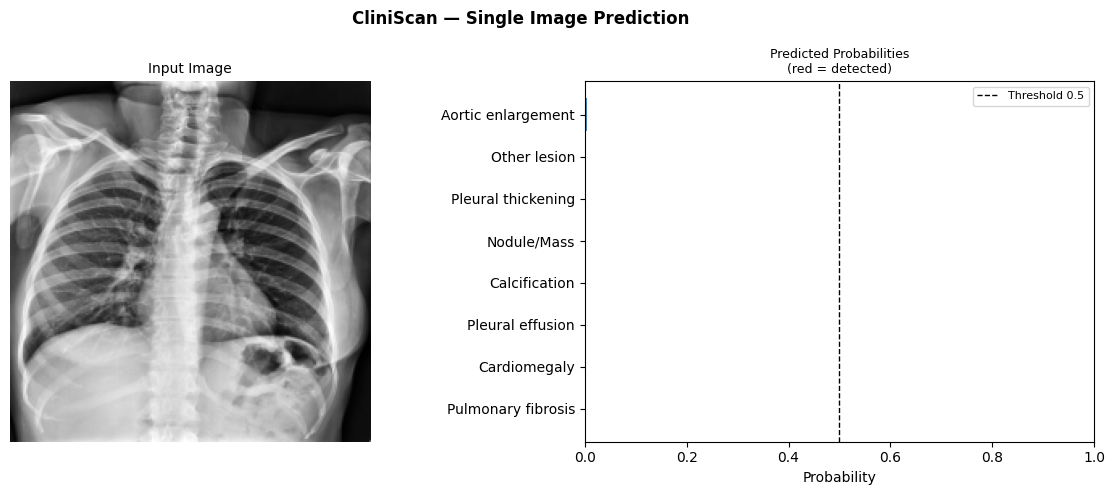

Detected findings (prob >= 0.5):
  No finding  (Normal)


In [19]:
def crop_borders(img, pct=0.02):
    h, w = img.shape[:2]
    t = int(h * pct);  b = int(h * (1 - pct))
    l = int(w * pct);  r = int(w * (1 - pct))
    return cv2.resize(img[t:b, l:r], (w, h), interpolation=cv2.INTER_AREA)

def predict(img_path, threshold=0.5):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = crop_borders(img, pct=0.02)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    tensor = eval_transform(img).unsqueeze(0)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(tensor)).numpy()[0]
    findings = [(CLASS_NAMES[i], float(probs[i])) for i in range(NUM_CLASSES) if probs[i] >= threshold]
    findings.sort(key=lambda x: -x[1])
    return probs, findings

# Test on a random image
sample_id   = random.choice(test_ids)
sample_path = os.path.join(PROCESSED_IMAGE_DIR, sample_id + '.png')
probs, findings = predict(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

img_display = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
axes[0].imshow(img_display, cmap='gray')
axes[0].set_title(f"Input Image", fontsize=10)
axes[0].axis('off')

top_idx   = np.argsort(probs)[::-1][:8]
top_probs = probs[top_idx]
top_names = [CLASS_NAMES[i] for i in top_idx]
colors    = ['crimson' if p >= 0.5 else 'steelblue' for p in top_probs]

axes[1].barh(top_names[::-1], top_probs[::-1], color=colors[::-1])
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=1, label='Threshold 0.5')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Probability')
axes[1].set_title('Predicted Probabilities\n(red = detected)', fontsize=9)
axes[1].legend(fontsize=8)

plt.suptitle('CliniScan — Single Image Prediction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_prediction.png'), dpi=100)
plt.show()

print("Detected findings (prob >= 0.5):")
if findings:
    for name, prob in findings:
        print(f"  ✅  {name:<25}  {prob:.3f}")
else:
    print("  No finding  (Normal)")